In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")
from src.preprocessing import *
from src.feature_engineering import create_features
from src.anomaly_models import run_anomaly_models
from src.visualization import *
import glob
import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [13]:
data_path = "../data/BDG2/raw/*.csv"

df = load_data(data_path)

# df.info()
# df.head()
# df.describe() 

Total files found: 18
Data loaded successfully!
Shape: (613506, 1677)


In [ ]:
df = preprocess_data(df)

df.head()

Number of building columns: 136
Shape after melt: (83436816, 3)
Shape: (9623164, 3)
Missing values: 0
Timestamp dtype: datetime64[us]
Sample dataset saved!


In [6]:
df = create_features(df)

df.head()
print(df.columns)

Shape after removing duplicates: (2348344, 12)
Index(['timestamp', 'building', 'meter_reading', 'hour', 'day_of_week',
       'month', 'is_weekend', 'rolling_mean_7d', 'rolling_std_7d',
       'deviation_from_baseline', 'lag1', 'lag24'],
      dtype='str')


In [7]:
# Preparing Feature Matrix
features = [
    "meter_reading",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "rolling_mean_7d",
    "rolling_std_7d",
    "deviation_from_baseline",
    "lag1",
    "lag24"
]

X = df[features]

In [ ]:
df, iso = run_anomaly_models(df, X)

df["final_anomaly"].value_counts(normalize=True)

h:\VS\Internship Project\Energy Anomaly Detection\venv\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
h:\VS\Internship Project\Energy Anomaly Detection\venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (28.470537913572787 > -0.693658672901886). You may want to try with a higher value of support_fraction (current value: 0.800).
  warnings.warn(
h:\VS\Internship Project\Energy Anomaly Detection\venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (33.899051548768519 > 13.273880579771248). You may want to try with a higher value of support_fraction (current value: 0.800).
  warnings.warn(
h:\VS\Internship Project\Energy Anoma

final_anomaly
0    0.959165
1    0.040835
Name: proportion, dtype: float64

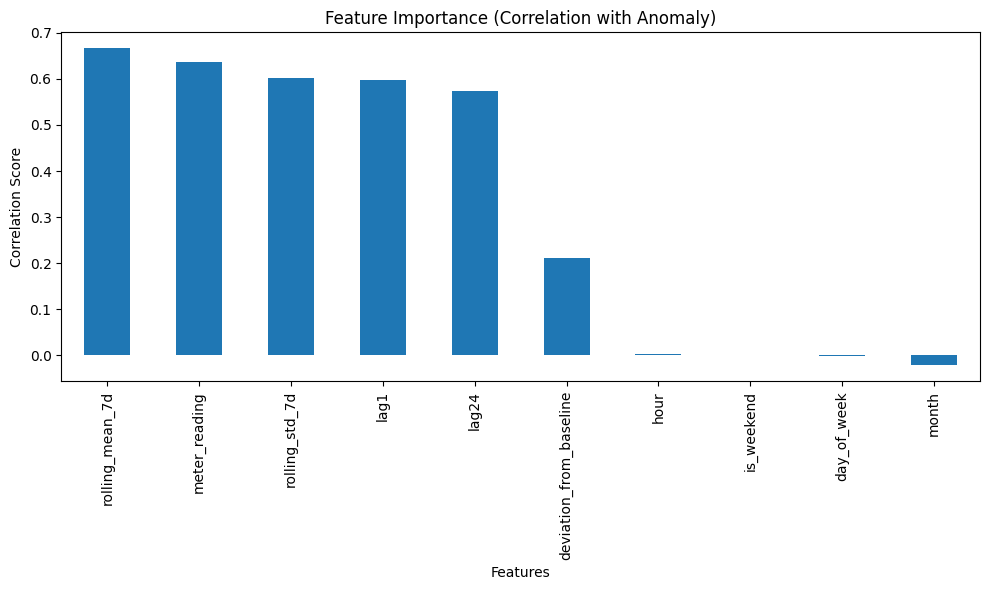

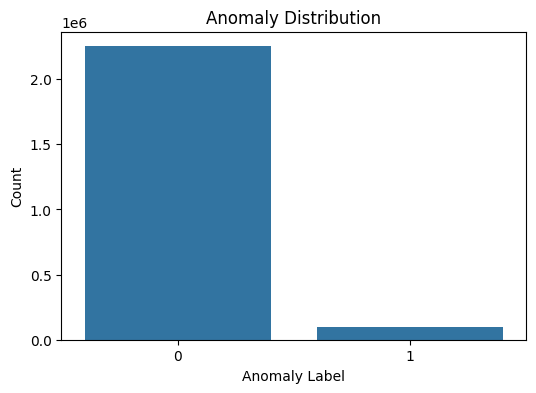

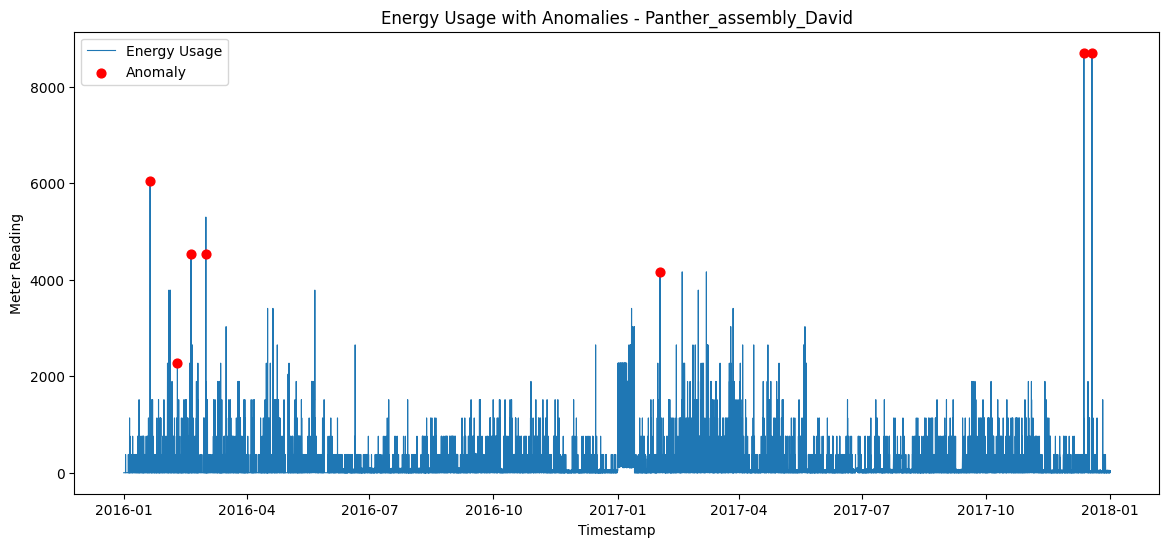

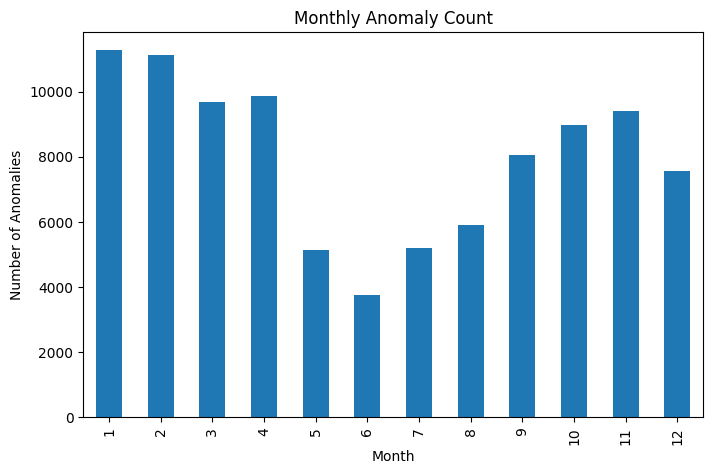

In [9]:
plot_feature_importance(df, features)

plot_anomaly_distribution(df)

plot_energy_anomalies(df)

plot_monthly_anomalies(df)

Estimated cost of anomalies (₹): 2681582539.8111997


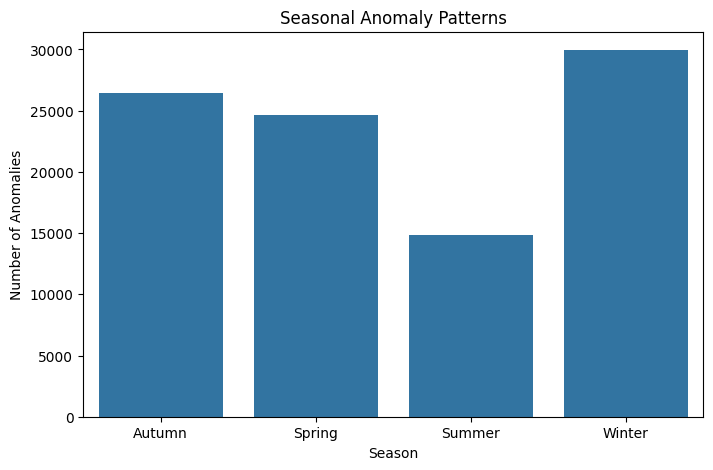

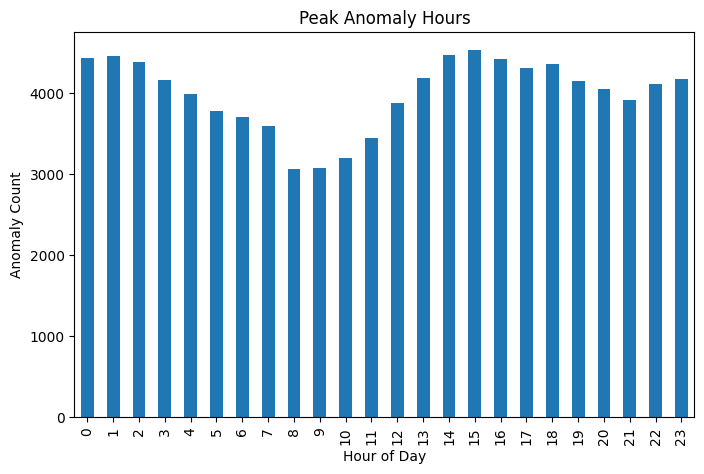

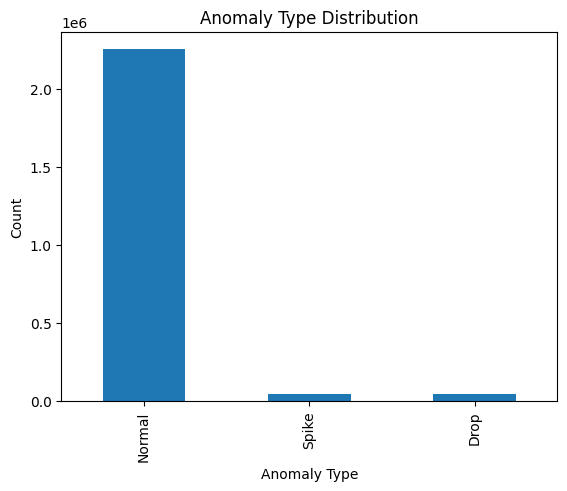

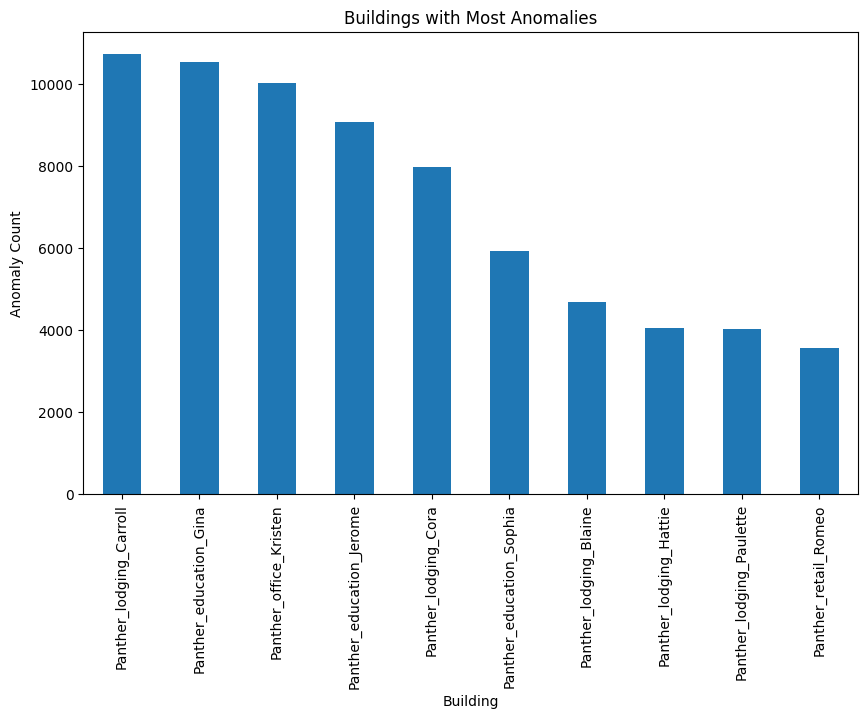

In [10]:
# Business Insights and Impact

electricity_price = 8  # Rs 8 per kWh

df["anomaly_cost"] = df["meter_reading"] * electricity_price * df["final_anomaly"]

total_anomaly_cost = df["anomaly_cost"].sum()

print("Estimated cost of anomalies (₹):", total_anomaly_cost)

# Seasonal anamoly patterns

# Create season column based on month
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

# Count anomalies in each season
seasonal_anomalies = df[df["final_anomaly"] == 1].groupby("season").size()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=seasonal_anomalies.index, y=seasonal_anomalies.values)

plt.title("Seasonal Anomaly Patterns")
plt.xlabel("Season")
plt.ylabel("Number of Anomalies")

plt.savefig("../results/seasonal_anomalies.png")
plt.show()

# Anomaly by hours
hourly_anomalies = df.groupby("hour")["final_anomaly"].sum()

plt.figure(figsize=(8,5))
hourly_anomalies.plot(kind="bar")

plt.title("Peak Anomaly Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Anomaly Count")

plt.savefig("../results/peak_anomaly_hours.png")
plt.show()

# Anomaly Patterns
import numpy as np

df["anomaly_type"] = np.where(
    df["final_anomaly"] == 0,
    "Normal",
    np.where(df["deviation_from_baseline"] > 0, "Spike", "Drop")
)

df["anomaly_type"].value_counts()

df["anomaly_type"].value_counts().plot(kind="bar")

plt.title("Anomaly Type Distribution")
plt.xlabel("Anomaly Type")
plt.ylabel("Count")

plt.savefig("../results/anomaly_types.png")
plt.show()

# Buildings with most anomalies
top_buildings = (
    df[df["final_anomaly"] == 1]
    .groupby("building")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_buildings.plot(kind="bar")

plt.title("Buildings with Most Anomalies")
plt.xlabel("Building")
plt.ylabel("Anomaly Count")

plt.savefig("../results/top_buildings_anomalies.png")
plt.show()